# Results Explained

This notebook loads the saved router result data and creates simple visualizations for comparing model groups, baselines, and router performance.

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

ROOT = Path.cwd().resolve()
if ROOT.name in {"results", "notebooks"}:
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "results"
summary_path = RESULTS_DIR / "router_model_results_summary.csv"

router_results_df = pd.read_csv(summary_path)
numeric_columns = ["test_mae", "test_mse", "test_rmse"]
router_results_df[numeric_columns] = router_results_df[numeric_columns].apply(pd.to_numeric)

print(f"Loaded {len(router_results_df)} rows from {summary_path}")
display(router_results_df.round({"test_mae": 6, "test_mse": 6, "test_rmse": 6}))

Loaded 31 rows from C:\Users\luwil\OneDrive\Documents\Code\BasicTS\results\router_model_results_summary.csv


,model_count,model_group,selected_models,method,test_mae,test_mse,test_rmse
0,1,best_1_expert,DLinear,DLinear,0.347951,0.331419,0.575690
1,2,best_2_experts,DLinear + TimesNet,Fixed validation-based soft weights,0.340855,0.320081,0.565757
2,2,best_2_experts,DLinear + TimesNet,Fixed equal average,0.340907,0.320136,0.565806
3,2,best_2_experts,DLinear + TimesNet,Learned prediction-aware router,0.347806,0.327268,0.572074
4,2,best_2_experts,DLinear + TimesNet,DLinear,0.347951,0.331419,0.575690
5,2,best_2_experts,DLinear + TimesNet,Validation-selected best expert,0.347951,0.331419,0.575690
6,2,best_2_experts,DLinear + TimesNet,TimesNet,0.366520,0.352346,0.593588
7,3,best_3_experts,DLinear + iTransformer + ModernTCN,Learned prediction-aware router,0.338889,0.309635,0.556448
8,3,best_3_experts,DLinear + iTransformer + ModernTCN,Fixed validation-based soft weights,0.342275,0.312099,0.558658
9,3,best_3_experts,DLinear + iTransformer + ModernTCN,Fixed equal average,0.342925,0.312688,0.559185


## Best Method Per Model Count

In [15]:
best_by_count_df = (
    router_results_df.sort_values(["model_count", "test_mae"], ignore_index=True)
    .groupby("model_count", as_index=False)
    .first()
)

display(
    best_by_count_df[
        ["model_count", "selected_models", "method", "test_mae", "test_mse", "test_rmse"]
    ].round({"test_mae": 6, "test_mse": 6, "test_rmse": 6})
)

,model_count,selected_models,method,test_mae,test_mse,test_rmse
0,1,DLinear,DLinear,0.347951,0.331419,0.575690
1,2,DLinear + TimesNet,Fixed validation-based soft weights,0.340855,0.320081,0.565757
2,3,DLinear + iTransformer + ModernTCN,Learned prediction-aware router,0.338889,0.309635,0.556448
3,4,DLinear + iTransformer + TimesNet + ModernTCN,Learned prediction-aware router,0.338982,0.310926,0.557607
4,5,DLinear + PatchTST + iTransformer + TimesNet +...,Fixed validation-based soft weights,0.339299,0.310752,0.557451


## Best MAE By Model Count

## Learned Router Results

The one-model case has no learned router because there is no expert choice to make.

In [16]:
router_only_df = router_results_df[
    router_results_df["method"].eq("Learned prediction-aware router")
].copy()

display(
    router_only_df[
        ["model_count", "selected_models", "method", "test_mae", "test_mse", "test_rmse"]
    ].round({"test_mae": 6, "test_mse": 6, "test_rmse": 6})
)

,model_count,selected_models,method,test_mae,test_mse,test_rmse
3,2,DLinear + TimesNet,Learned prediction-aware router,0.347806,0.327268,0.572074
7,3,DLinear + iTransformer + ModernTCN,Learned prediction-aware router,0.338889,0.309635,0.556448
14,4,DLinear + iTransformer + TimesNet + ModernTCN,Learned prediction-aware router,0.338982,0.310926,0.557607
24,5,DLinear + PatchTST + iTransformer + TimesNet +...,Learned prediction-aware router,0.340320,0.315812,0.561972


Saved chart to C:\Users\luwil\OneDrive\Documents\Code\BasicTS\results\results_explained_best_mae_by_count.png


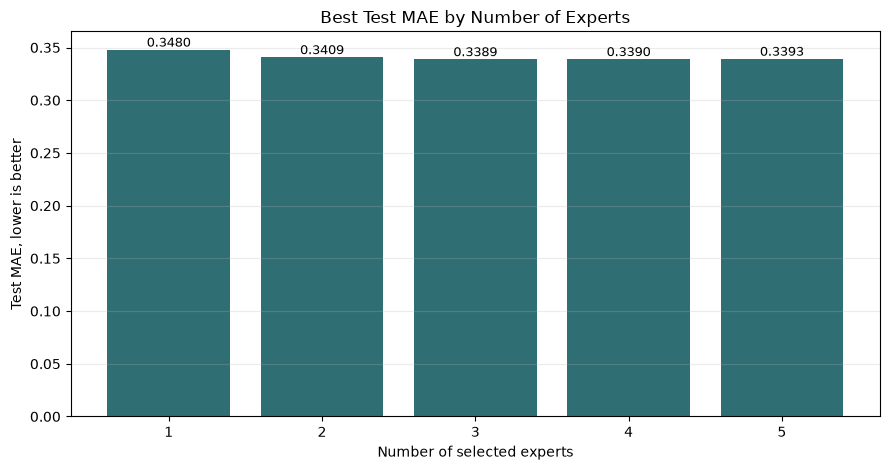

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar(
    best_by_count_df["model_count"].astype(str),
    best_by_count_df["test_mae"],
    color="#2f6f73",
)
ax.set_title("Best Test MAE by Number of Experts")
ax.set_xlabel("Number of selected experts")
ax.set_ylabel("Test MAE, lower is better")
ax.grid(axis="y", alpha=0.25)
for bar, value in zip(bars, best_by_count_df["test_mae"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
output_path = RESULTS_DIR / "results_explained_best_mae_by_count.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
print(f"Saved chart to {output_path}")
plt.show()

## Router And Baseline Comparison

method,Learned prediction-aware router,Fixed validation-based soft weights,Fixed equal average,Validation-selected best expert
model_count,,,,
2,0.347806,0.340855,0.340907,0.347951
3,0.338889,0.342275,0.342925,0.351190
4,0.338982,0.339045,0.339541,0.351190
5,0.340320,0.339299,0.339679,0.351190


Saved chart to C:\Users\luwil\OneDrive\Documents\Code\BasicTS\results\results_explained_router_vs_baselines.png


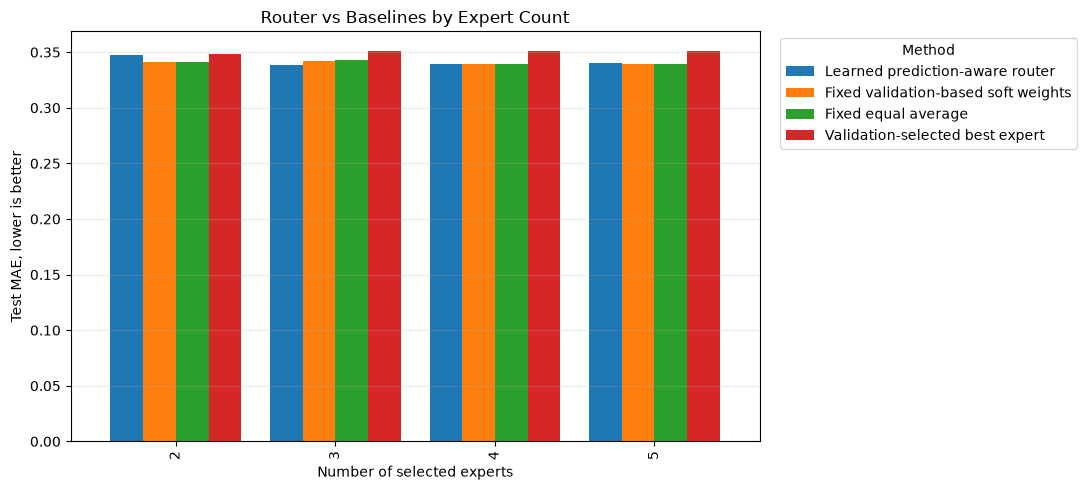

In [18]:
comparison_methods = [
    "Learned prediction-aware router",
    "Fixed validation-based soft weights",
    "Fixed equal average",
    "Validation-selected best expert",
]
comparison_df = router_results_df[router_results_df["method"].isin(comparison_methods)].copy()
pivot_df = comparison_df.pivot_table(
    index="model_count",
    columns="method",
    values="test_mae",
    aggfunc="first",
).sort_index()
pivot_df = pivot_df[[method for method in comparison_methods if method in pivot_df.columns]]

display(pivot_df.round(6))

ax = pivot_df.plot(kind="bar", figsize=(11, 5), width=0.82)
ax.set_title("Router vs Baselines by Expert Count")
ax.set_xlabel("Number of selected experts")
ax.set_ylabel("Test MAE, lower is better")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
output_path = RESULTS_DIR / "results_explained_router_vs_baselines.png"
plt.savefig(output_path, dpi=160, bbox_inches="tight")
print(f"Saved chart to {output_path}")
plt.show()

## Oracle Combination Potential

,number_of_experts,combination,oracle_mae
0,2,Candidate_DLinear + Candidate_TimesNet,0.377791
1,3,Candidate_DLinear + Candidate_iTransformer + C...,0.365208
2,4,Candidate_DLinear + Candidate_iTransformer + C...,0.359040
3,5,Candidate_DLinear + Candidate_PatchTST + Candi...,0.355949


Saved chart to C:\Users\luwil\OneDrive\Documents\Code\BasicTS\results\results_explained_oracle_mae_by_count.png


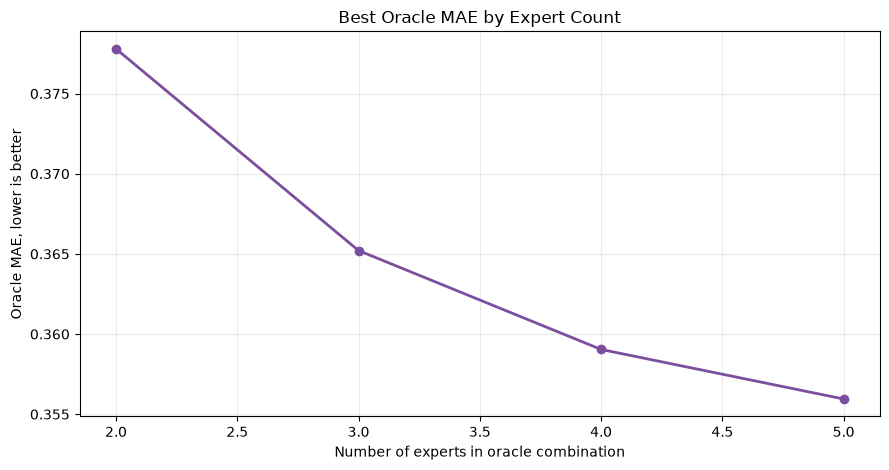

In [19]:
oracle_path = RESULTS_DIR / "candidate_expert_combinations.csv"
if oracle_path.exists():
    oracle_df = pd.read_csv(oracle_path)
    oracle_df["oracle_mae"] = pd.to_numeric(oracle_df["oracle_mae"])
    best_oracle_by_size_df = (
        oracle_df.sort_values(["number_of_experts", "oracle_mae"], ignore_index=True)
        .groupby("number_of_experts", as_index=False)
        .first()
    )
    display(best_oracle_by_size_df[["number_of_experts", "combination", "oracle_mae"]].round({"oracle_mae": 6}))

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.plot(
        best_oracle_by_size_df["number_of_experts"],
        best_oracle_by_size_df["oracle_mae"],
        marker="o",
        linewidth=2,
        color="#7a4f9f",
    )
    ax.set_title("Best Oracle MAE by Expert Count")
    ax.set_xlabel("Number of experts in oracle combination")
    ax.set_ylabel("Oracle MAE, lower is better")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    output_path = RESULTS_DIR / "results_explained_oracle_mae_by_count.png"
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Saved chart to {output_path}")
    plt.show()
else:
    print(f"No oracle combination file found at {oracle_path}")

## Extra Router Result Files

In [20]:
extra_patterns = [
    "routerdc_hard_test_comparison.csv",
    "router2_test_comparison.csv",
    "router2_*_test_comparison.csv",
]
extra_files = []
for pattern in extra_patterns:
    extra_files.extend(sorted(RESULTS_DIR.glob(pattern)))

seen = set()
extra_files = [path for path in extra_files if not (path in seen or seen.add(path))]

if not extra_files:
    print("No extra Router2 or RouterDC comparison files found yet.")
else:
    for path in extra_files:
        print(path.relative_to(ROOT))
        df = pd.read_csv(path)
        for column in ["Test MAE", "Test MSE", "Test RMSE"]:
            if column in df.columns:
                df[column] = pd.to_numeric(df[column])
        display(df.round(6))

No extra Router2 or RouterDC comparison files found yet.
